# Poiseuille - BGK - Zou-He Constant Velocity Inlet and Outlet

In [171]:
# Python Imports
from pylab import *
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors
from IPython.display import display, Math, Latex

In [172]:
#------------Lattice Parameters----------------
w0=4.0/9.0;w1=1.0/9.0;w2=1.0/36.0; # Lattice Weights
w = np.array([w0,w1,w1,w1,w1,w2,w2,w2,w2],dtype="float64") 
cx = np.array([0,1,0,-1, 0,1,-1,-1, 1],dtype="int8")  # Lattice Directions
cy = np.array([0,0,1, 0,-1,1, 1,-1,-1],dtype="int8")  # Lattice Directions
#------------Dimensionless Parameter----------------
ho = 1.0 # Dimensionless Domain Length
nuo = 0.1 #Dimensionless Kinematic Viscosity

The problem scaling follow the equations:
$$
\Delta x=\frac{H_{0}}{Nx}, \quad \quad r=\frac{\Delta x}{\Delta t}, \quad \quad u=u_{0}\frac{\Delta t}{\Delta x}, \quad \quad \textrm{and} \quad \quad \nu=\nu_{0}\frac{\Delta t}{\Delta x^{2}}
$$
where $\Delta x $ is grid size, $\Delta y$ is time step and $r$ is the relation term. Dimensionless numbers
$$
Re=\frac{u_{0}\rho H}{\mu}=\frac{u_{0} H}{\nu} \quad \quad \textrm{and} \quad \quad C_{d}=\frac{24}{Re}\frac{L}{H}.
$$

In [173]:
import time
#---------------Numerical Domain Size--------------------
cases=1
rtime=0.4
Nx0 = np.array([64],dtype="int64")
Ny0 = np.array([1],dtype="int64")
r0 = np.array([2.0**(3)],dtype="float64")
# mstep=int(rtime/ ((ho / Nx) / r))
# mstep0 = np.array([mstep*1],dtype="int64")
mstep0 = np.array([int(rtime/ ((ho / Nx) / r0))],dtype="int64")
rhor = np.empty(len(Nx0), dtype=object)
Vxr = np.empty(len(Nx0), dtype=object)
Vyr = np.empty(len(Nx0), dtype=object)
amp = np.empty(len(Nx0), dtype=object)
Mass = np.empty(len(Nx0), dtype=object)
for i in range(len(Nx0)):
    rhor[i] = np.zeros((int(Nx0[i]), int(Ny0[i])), dtype="float64")
    Vxr[i] = np.zeros((int(Nx0[i]), int(Ny0[i])), dtype="float64")
    Vyr[i] = np.zeros((int(Nx0[i]), int(Ny0[i])), dtype="float64")
    amp[i] = np.zeros((int(mstep0[i])), dtype="float64")
    Mass[i] = np.zeros((int(mstep0[i])), dtype="float64")
for case in range(0,cases):
    Nx=Nx0[case]
    Ny=Ny0[case]
    xlin=np.linspace(0.5,Nx-0.5,Nx)
    #------------------------------------------Scaling Term--------------------------------------------
    dx = ho / Nx # Grid size 
    r = r0[case] # Relation term r=dx/dt
    dt = dx / r # Time Step
    #----------------------------------------LBM-Scale-----------------------------------------------
    nu = dt * nuo / (dx * dx)  #Scaling Viscosity
    cs = 1.0 / sqrt(3.) #Sound Speed
    tau = (nu/ (cs * cs)) + (1.0/ 2.0) #Relaxation time
    rhoi = 1.0 #Initial Densty
    drho = 1E-6 #drho
    pi = 3.141592653589793238462643383279502884;
    #--------------Print-Data-------------------------------------------------------------------------
    display(Math(r"\tau="+str(tau)+r"\quad\quad \nu="+str(nu)))
    display(Math(r"r="+str(r)+r"\quad\quad \nu="+str(nu)))
    display(Math(r"dx="+str(dx)+r"\quad\quad dt="+str(dt)+r"\quad\quad mstep="+str(mstep0[case])))
    #---------------------Field-Arrays---------------------------------------------------------------- 
    rho=np.zeros((Nx,Ny),dtype="float64") # Allocating Density field
    rho[:,0]=rhoi + drho * sin( 2*pi*(xlin[:])/Nx ); # Constant initial density field
    Vx=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity x Field
    Vy=np.zeros((Nx,Ny),dtype="float64") # Allocating Null Velocity y Field
    #----------------Initializing Distribution Functions----------------
    f=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pre-Collisional Distribution Function
    fp=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
    feq=np.zeros((9,Nx,Ny),dtype="float64") # Allocating Pos-Collisional Distribution Function
    for k in range (0,9):
        f[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
    #---------------------------------Main-Loop-------------------------------------------------------
    start=time.time()
    for kk in range(0,mstep0[case]):
        #-------------------------------------Convergence------------------------------------------------------------------------
        amp[case][kk] = (rho[Nx//4,0] - 1)/drho;
        rho_med = np.sum(rho)/(Nx*Ny)
        Mass[case][kk] = rho_med
        #------------------------------------Collision-----------------------------------------------------------------------------
        for k in range(0,9):
            feq[k,:,:]=w[k]*rho*(1. + 3.*(Vx*cx[k]+Vy*cy[k]) + 4.5*(Vx*cx[k]+Vy*cy[k])**2-1.5*(Vx*Vx+Vy*Vy))
            fp[k,:,:]=f[k,:,:]-(1.0/tau)*(f[k,:,:]-feq[k,:,:])
        #----------------------------------Streaming---------------------------------------------------------------------------
        for k in range(0,9):
            f[k,:,:]=np.roll(np.roll(fp[k,:,:], cx[k], axis=0), cy[k], axis=1)
        #--------------------------------------Macro-Properties------------------------------------------------------------------
        rho= np.einsum('ixy->xy', f)
        Vx=np.divide(np.einsum('i,ixy->xy', cx, f), rho, out=np.zeros_like(Vx, dtype="float64"), where=rho!=0)
        Vy=np.divide(np.einsum('i,ixy->xy', cy, f), rho, out=np.zeros_like(Vy, dtype="float64"), where=rho!=0)
        if (kk%1000==0):
            Umed = np.sum(Vx)/(Nx*Ny)
            rho_med = np.sum(rho)/(Nx*Ny)
            print('Umed=',Umed)
    rhor[case]=rho
    Vxr[case]=Vx
    Vyr[case]=Vy

/tmp/ipykernel_29369/3663880817.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mstep0 = np.array([int(rtime/ ((ho / Nx) / r0))],dtype="int64")


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Umed= 2.0679515313825692e-25


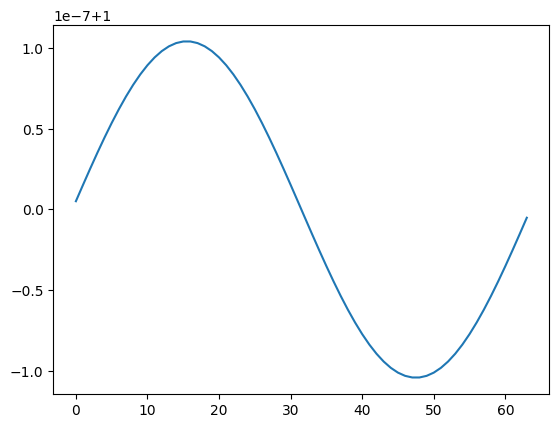

In [174]:
plt.plot(rho)

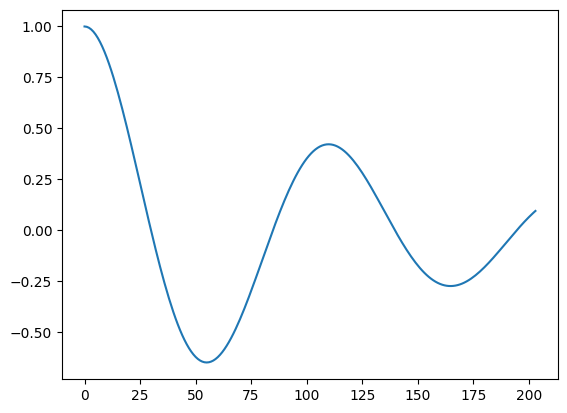

In [175]:
plt.plot(amp[0])

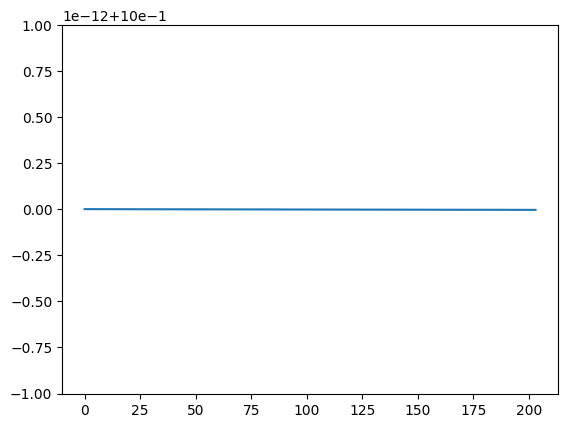

In [176]:
plt.plot(Mass[0])

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import os
import glob

# k = 2*np.pi/Nx
# w=k*cs*(1.0-(2.0*nu*k/cs)**2)**(1/2)
# rhoana = drho*np.e**(2*nu)*np.cos(2*pi*(xlin[:])/Nx + w*mstep)
# rhoana2 = drho*np.e**(2*nu)*np.sin(2*pi*(xlin[:])/Nx + w*mstep)

p = amp[0]
t = np.arange( p.size )
cs = 1/np.sqrt(3)
k = 2*np.pi/Nx
nu  = cs**2 * (tau-0.5)
nup = 2/3*nu
sigma = -(2/3*nu + 1/2 * nup)*k**2 + 1j* k * cs * np.sqrt(1 - (4/3*nu+nup)**2 * k**2 / cs**2 )

w_a = sigma.imag
lbd_a = - sigma.real
ampana = drho * np.exp(- lbd_a * t) * np.cos(w_a * t)

def waveSol(t, A, lbd, w):
    return A * np.exp(- lbd * t) * np.cos(w * t)
    
(A_fit, lbd_fit, w_fit) , reg_cov = curve_fit( waveSol , t, p, p0 = (1.0, lbd_a, w_a)  )
ampana2 = drho * np.exp(- lbd_fit * t) * np.cos(w_fit * t)
# lbd = fitCurve( folder, tau, L ) 
   

In [188]:
print(lbd_fit)
print(lbd_a)

0.008262026291405877
0.007710628438351061


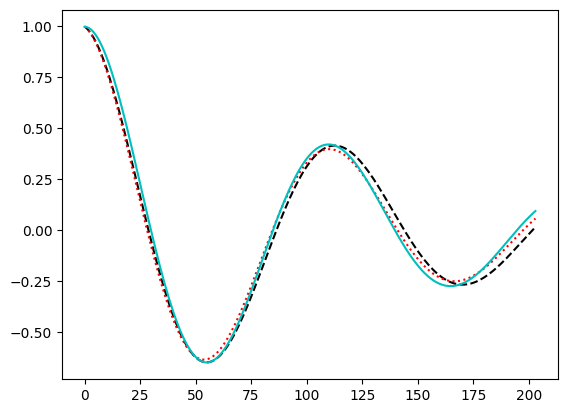

In [193]:
plt.plot(ampana/drho,'k--')
plt.plot(ampana2/drho,'r:')
plt.plot(amp[0],'c-')

In [168]:
print(t)
print(amp[0][:])
print(lbd_fit)
print(w_fit)
print(rhoana)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203]
[ 0.99879546  0.9971923   0.99239649  0.98444597  0.9733978   0.95932455
  0.94231181  0.92245626  0.89986433  0.87465104  0.8469391   0.81685811
  0.78454387  0.75013766 